In [4]:
# ── Imports ──────────────────────────────────────────────────
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
# from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi']        = 120
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False


In [ ]:

TICKER = ["TSLA", "BND", "SPY"]

data = yf.download(
    TICKER,
    start="2015-01-01",
    end="2026-07-01",
    auto_adjust=False,
    progress=False
)

# Convert from wide MultiIndex columns to long format
long_df = (
    data.stack(level=1)
        .rename_axis(index=["Date", "Ticker"])
        .reset_index()
)

print(long_df.head())

# Save
long_df.to_csv("../data/raw/tsla_bnd_spy_long.csv", index=False)


Price       Date Ticker   Adj Close       Close        High         Low  \
0     2015-01-02    BND   59.405388   82.650002   82.690002   82.419998   
1     2015-01-02    SPY  169.687866  205.429993  206.880005  204.179993   
2     2015-01-02   TSLA   14.620667   14.620667   14.883333   14.217333   
3     2015-01-05    BND   59.577919   82.889999   82.919998   82.699997   
4     2015-01-05    SPY  166.623352  201.720001  204.369995  201.350006   

Price        Open     Volume  
0       82.430000    2218800  
1      206.380005  121465900  
2       14.858000   71466000  
3       82.739998    5820100  
4      204.169998  169632600  


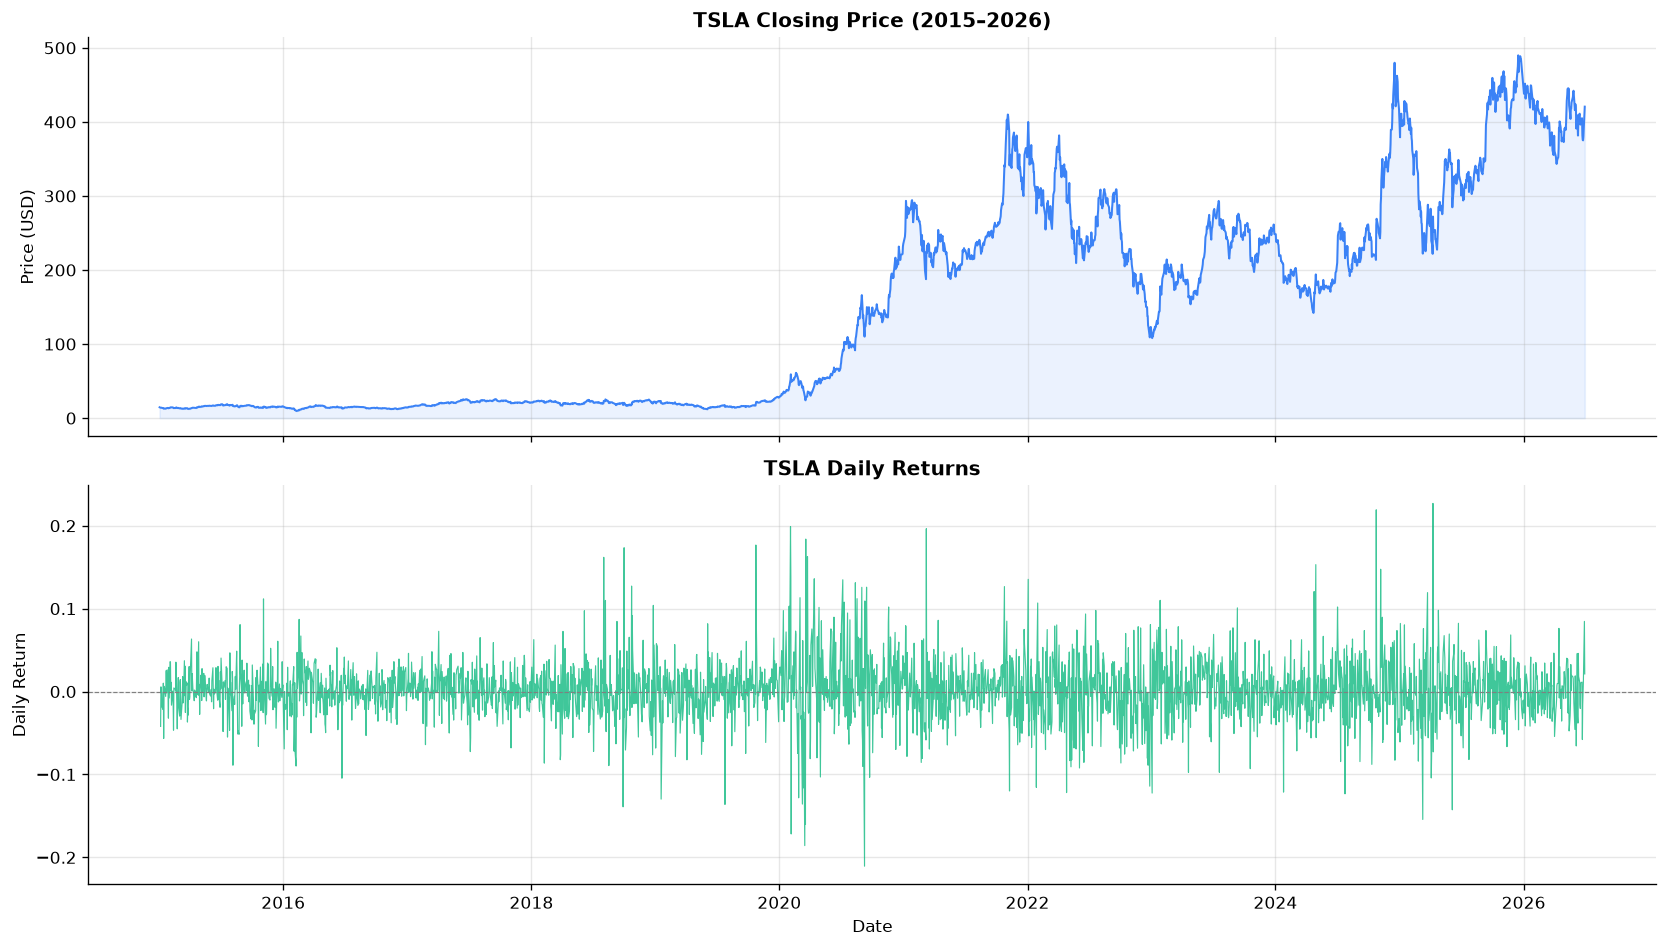


Summary statistics for TSLA:
count    2888.0000
mean        0.0018
std         0.0360
min        -0.2106
25%        -0.0166
50%         0.0012
75%         0.0195
max         0.2269
Name: Close, dtype: float64


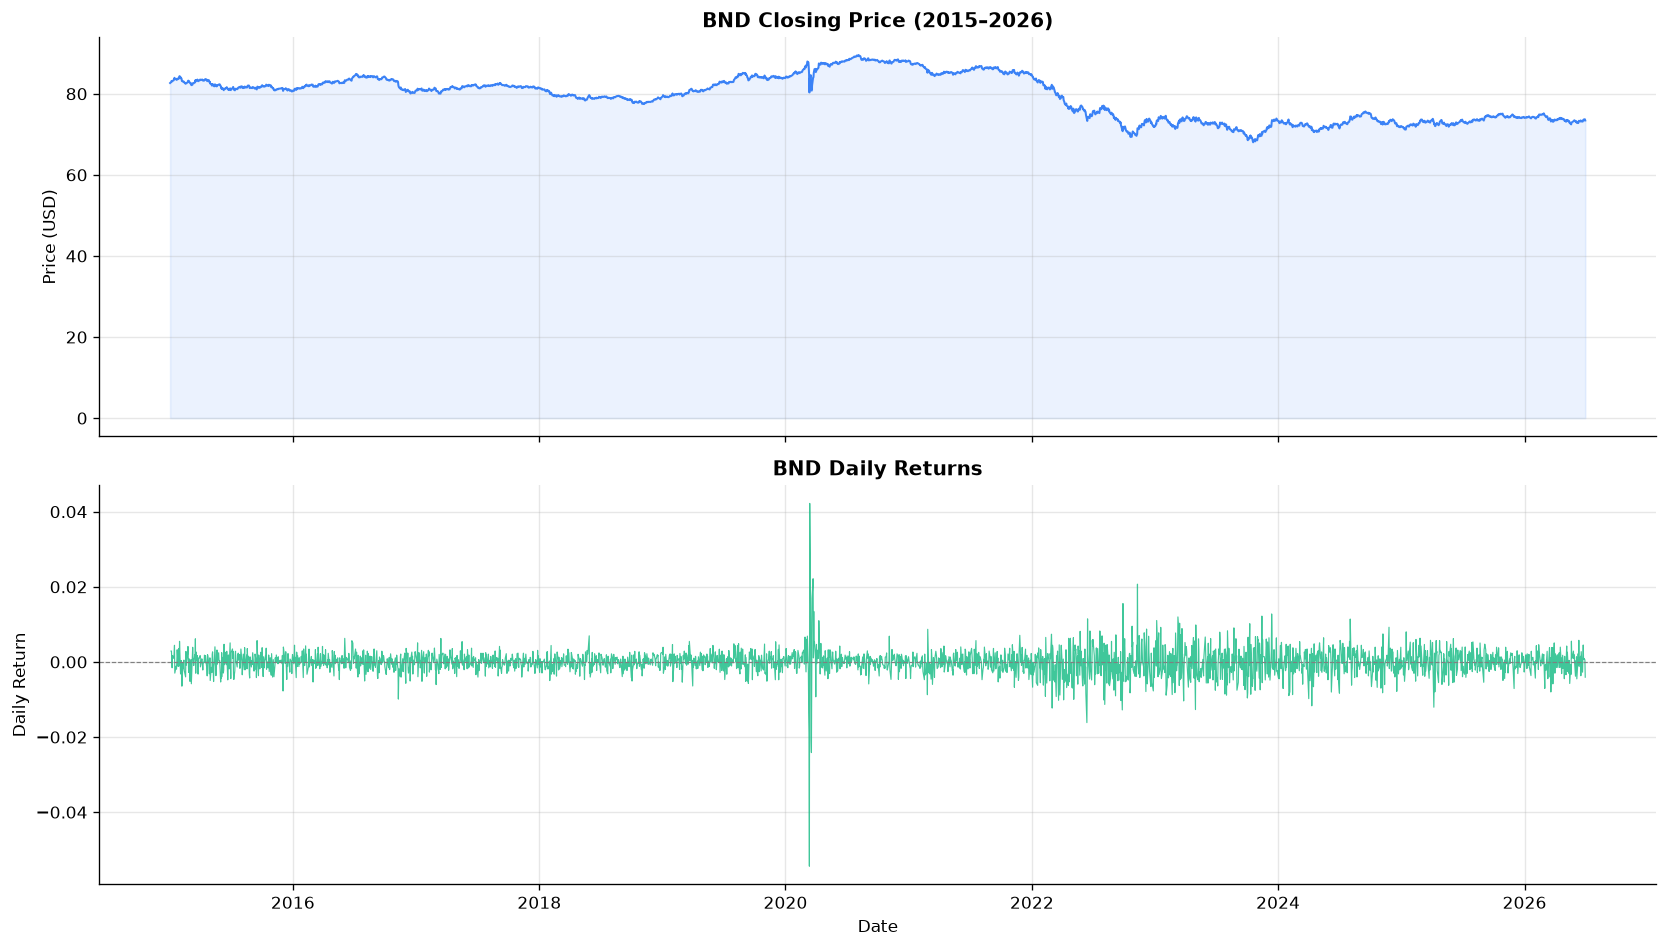


Summary statistics for BND:
count    2888.0000
mean       -0.0000
std         0.0034
min        -0.0544
25%        -0.0016
50%         0.0001
75%         0.0017
max         0.0422
Name: Close, dtype: float64


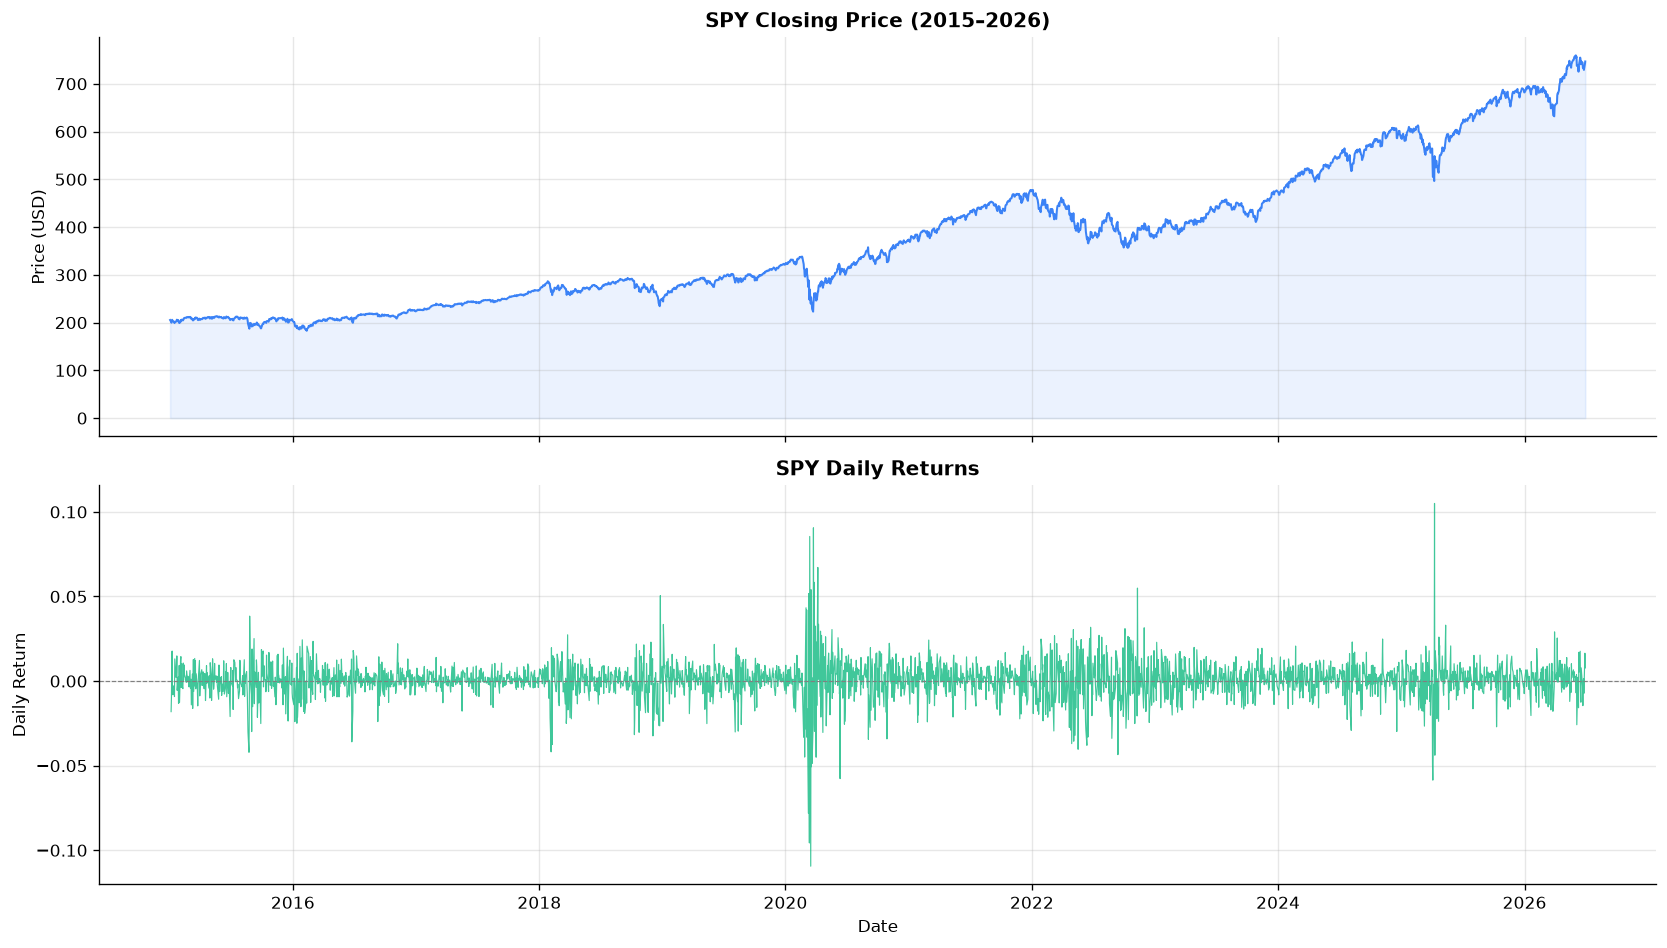


Summary statistics for SPY:
count    2888.0000
mean        0.0005
std         0.0112
min        -0.1094
25%        -0.0038
50%         0.0006
75%         0.0059
max         0.1050
Name: Close, dtype: float64


In [11]:
# Load data
df = pd.read_csv('../data/raw/tsla_bnd_spy_long.csv')

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# List of tickers
tickers = ['TSLA', 'BND', 'SPY']

for ticker in tickers:

    # Filter data for one ticker
    ticker_df = (
        df[df['Ticker'] == ticker]
        .sort_values('Date')
        .set_index('Date')
    )

    price = ticker_df['Close']
    returns = price.pct_change().dropna()

    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    # Closing price
    axes[0].plot(price.index, price, color='#3B82F6', linewidth=1.2)
    axes[0].fill_between(price.index, price, alpha=0.1, color='#3B82F6')
    axes[0].set_title(f'{ticker} Closing Price (2015–2026)',
                      fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Price (USD)')
    axes[0].grid(alpha=0.3)

    # Daily returns
    axes[1].plot(returns.index, returns,
                 color='#10B981', linewidth=0.7, alpha=0.8)
    axes[1].axhline(0, color='gray', linewidth=0.7, linestyle='--')
    axes[1].set_title(f'{ticker} Daily Returns',
                      fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Daily Return')
    axes[1].set_xlabel('Date')
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f'\nSummary statistics for {ticker}:')
    print(returns.describe().round(4))

In [14]:
def adf_test(series, name):
    result = adfuller(series.dropna())

    adf_stat = result[0]
    p_value = result[1]

    verdict = "STATIONARY ✅" if p_value < 0.05 else "NON-STATIONARY ❌"

    print(f"{name:<15} ADF={adf_stat:>9.4f}  p={p_value:.6f}  → {verdict}")

print("──────────── ADF Test Results ────────────")

for ticker in ['TSLA', 'BND', 'SPY']:

    ticker_df = (
        df[df['Ticker'] == ticker]
        .sort_values('Date')
        .set_index('Date')
    )

    price = ticker_df['Close']
    returns = price.pct_change().dropna()

    print(f"\n{ticker}")
    adf_test(price, "Price")
    adf_test(returns, "Returns")

──────────── ADF Test Results ────────────

TSLA
Price           ADF=  -1.0191  p=0.746225  → NON-STATIONARY ❌
Returns         ADF= -54.0042  p=0.000000  → STATIONARY ✅

BND
Price           ADF=  -1.0152  p=0.747691  → NON-STATIONARY ❌
Returns         ADF= -15.3173  p=0.000000  → STATIONARY ✅

SPY
Price           ADF=   1.0686  p=0.994939  → NON-STATIONARY ❌
Returns         ADF= -17.5048  p=0.000000  → STATIONARY ✅


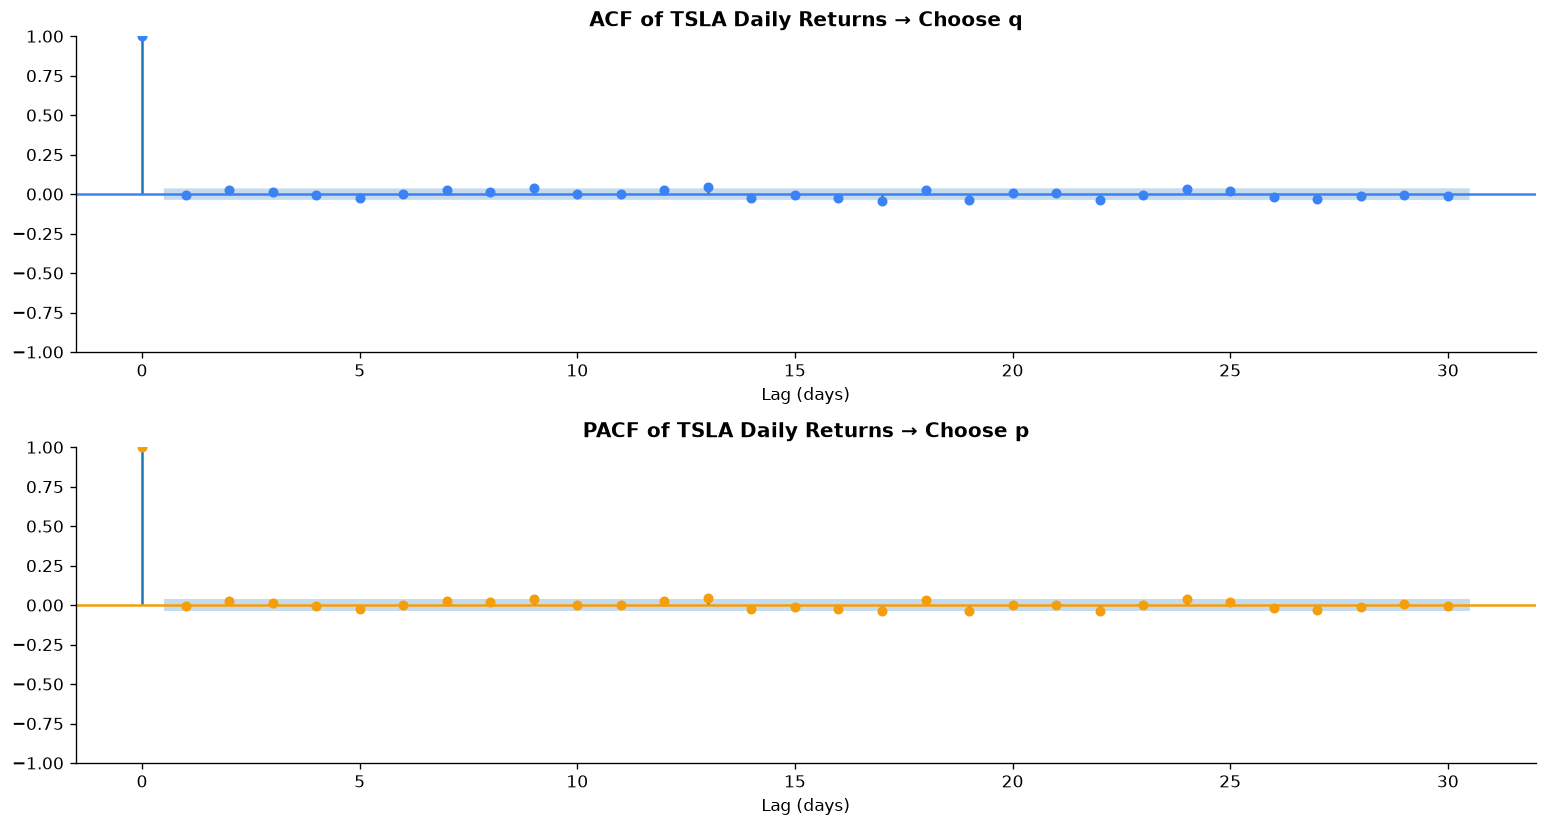


TSLA
• If the ACF cuts off at lag 1 → start with q = 1
• If the PACF cuts off at lag 1 → start with p = 1
• A good baseline model is ARIMA(1, 0, 1) on returns.


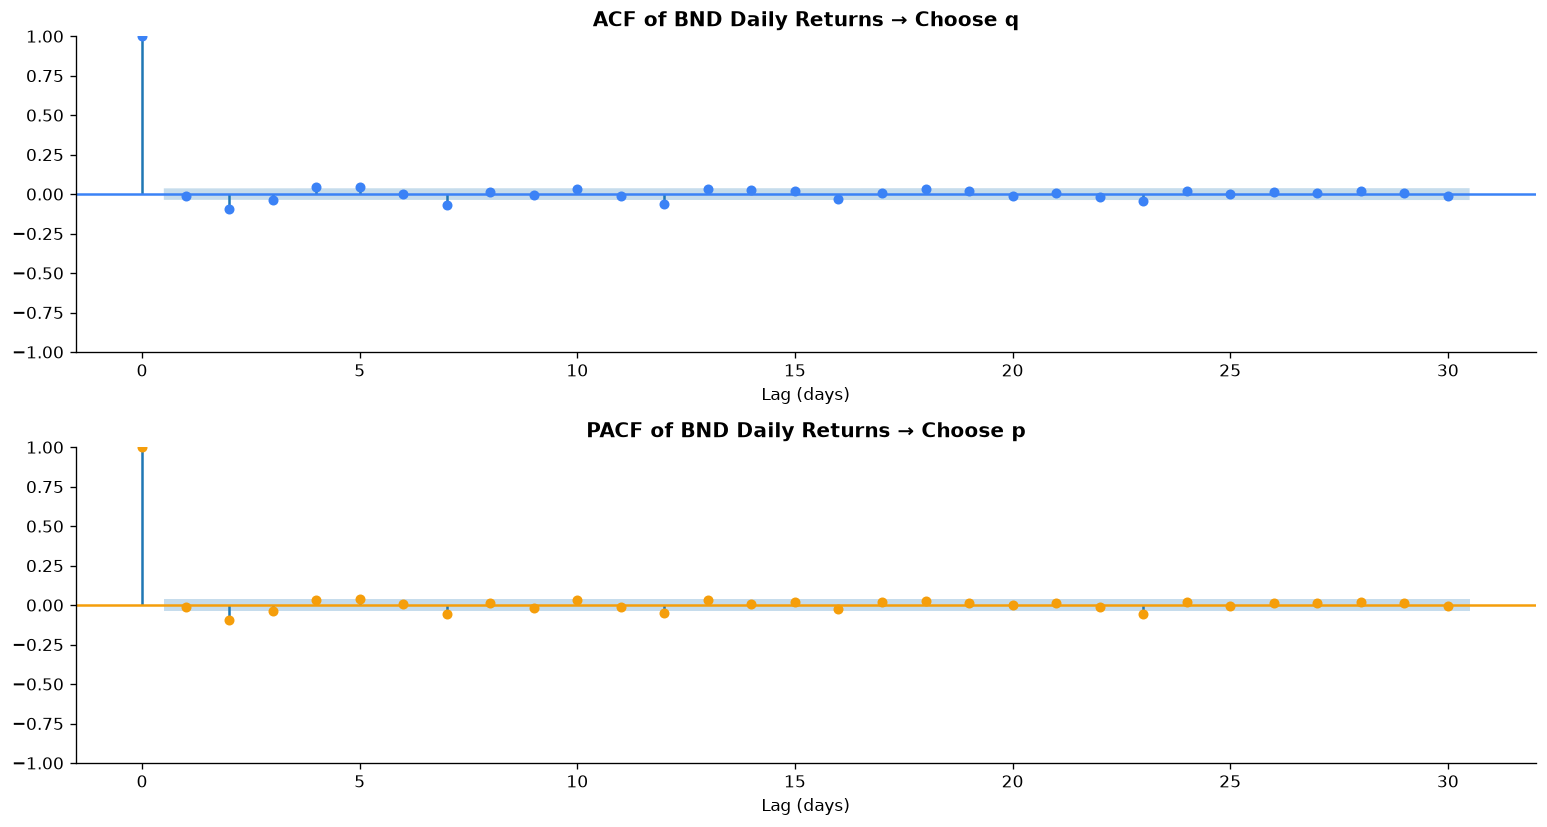


BND
• If the ACF cuts off at lag 1 → start with q = 1
• If the PACF cuts off at lag 1 → start with p = 1
• A good baseline model is ARIMA(1, 0, 1) on returns.


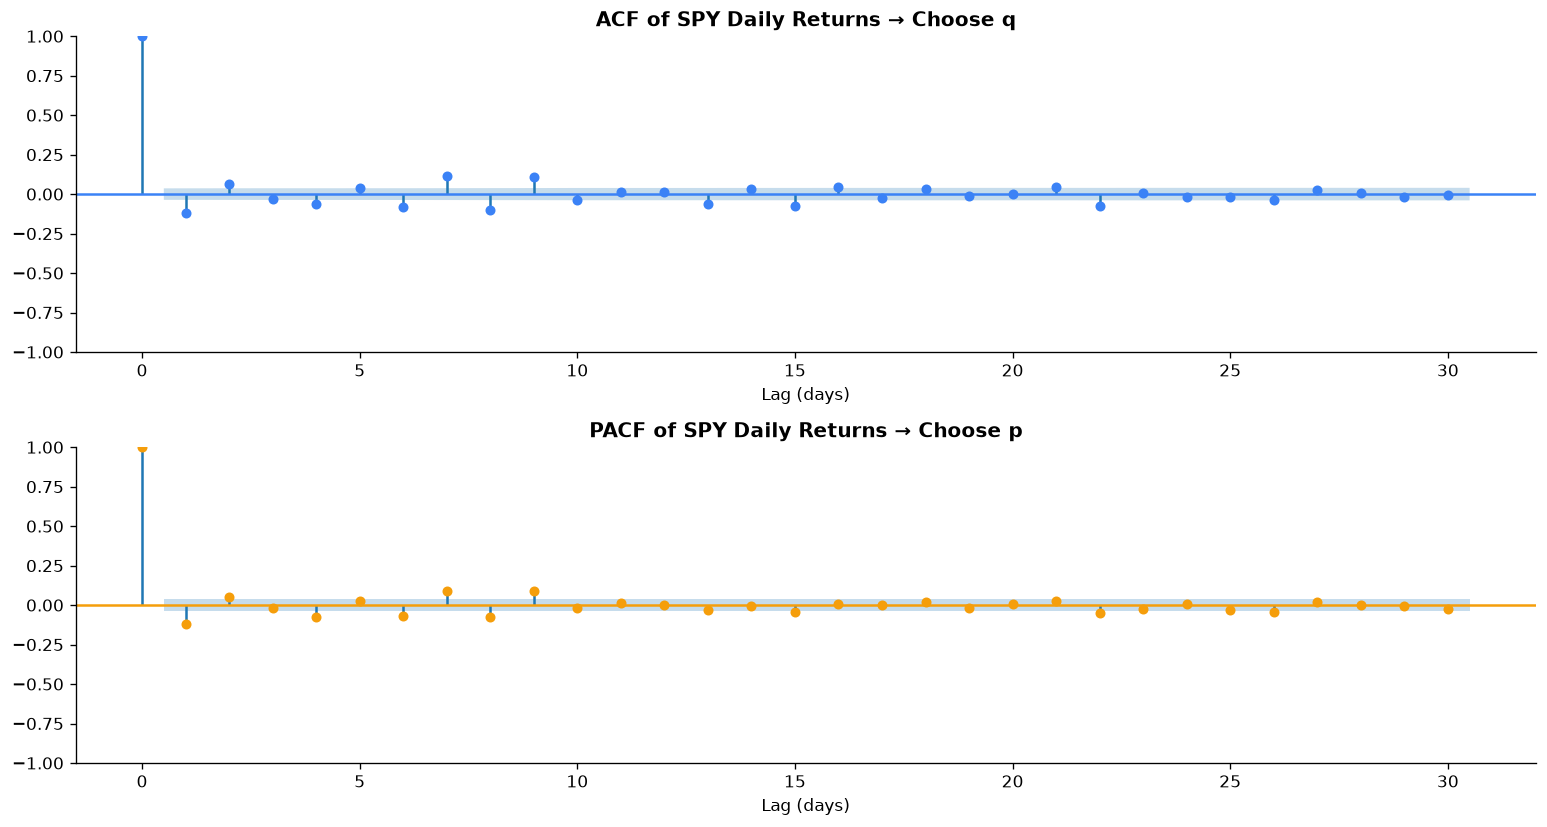


SPY
• If the ACF cuts off at lag 1 → start with q = 1
• If the PACF cuts off at lag 1 → start with p = 1
• A good baseline model is ARIMA(1, 0, 1) on returns.


In [16]:
tickers = ['TSLA', 'BND', 'SPY']

for ticker in tickers:

    ticker_df = (
        df[df['Ticker'] == ticker]
        .sort_values('Date')
        .set_index('Date')
    )

    returns = ticker_df['Close'].pct_change().dropna()

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7))

    # ACF
    plot_acf(
        returns,
        lags=30,
        ax=ax1,
        color='#3B82F6'
    )
    ax1.set_title(
        f'ACF of {ticker} Daily Returns → Choose q',
        fontsize=12,
        fontweight='bold'
    )
    ax1.set_xlabel('Lag (days)')

    # PACF
    plot_pacf(
        returns,
        lags=30,
        ax=ax2,
        color='#F59E0B',
        method='ywm'
    )
    ax2.set_title(
        f'PACF of {ticker} Daily Returns → Choose p',
        fontsize=12,
        fontweight='bold'
    )
    ax2.set_xlabel('Lag (days)')

    plt.tight_layout()
    plt.show()

    print(f"\n{ticker}")
    print("• If the ACF cuts off at lag 1 → start with q = 1")
    print("• If the PACF cuts off at lag 1 → start with p = 1")
    print("• A good baseline model is ARIMA(1, 0, 1) on returns.")

In [17]:
TRAIN_END = "2024-12-31"
# Chronological split
train_price   = price.loc[:TRAIN_END]
test_price    = price.loc[TRAIN_END:].iloc[1:]   # skip overlap row
train_returns = returns.loc[:TRAIN_END]
test_returns  = returns.loc[TRAIN_END:].iloc[1:]
print(f'Training : {len(train_price):4d} days  ({train_price.index[0].date()} → {train_price.index[-1].date()})')
print(f'Test     : {len(test_price):4d} days  ({test_price.index[0].date()} → {test_price.index[-1].date()})')

Training : 2516 days  (2015-01-02 → 2024-12-31)
Test     :  373 days  (2025-01-02 → 2026-06-30)


In [20]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train_returns, order=(1, 0, 1))
model_fit = model.fit()
# Forecast returns
n_steps = len(test_returns)

fc_result = model_fit.get_forecast(steps=n_steps)
fc_returns_arr = fc_result.predicted_mean.values

# Align index with test set
fc_returns_s = pd.Series(fc_returns_arr, index=test_returns.index)

# ── Convert returns → prices ──
last_train_price = float(train_price.iloc[-1])

fc_prices_arr = last_train_price * np.cumprod(1 + fc_returns_arr)

# Convert to Series (IMPORTANT: keeps datetime index)
fc_prices = pd.Series(fc_prices_arr, index=test_returns.index)

# ── Confidence interval (√t scaling approximation) ──
daily_std = float(train_returns.std())
days_ahead = np.arange(1, n_steps + 1)

price_band = last_train_price * daily_std * np.sqrt(days_ahead)
z = 1.96

fc_upper_arr = fc_prices_arr + z * price_band
fc_lower_arr = fc_prices_arr - z * price_band

fc_upper = pd.Series(fc_upper_arr, index=test_returns.index)
fc_lower = pd.Series(fc_lower_arr, index=test_returns.index)

# ── Summary outputs ──
print(f"Last known price : ${last_train_price:.2f}")
print(f"Daily return std : {daily_std*100:.3f}%")
print()

print(f"{'Horizon':>10} {'Forecast':>12} {'Lower':>12} {'Upper':>12} {'Width':>12}")
print("-" * 65)

checkpoints = [1, 5, 20, 60, n_steps]

for d in checkpoints:
    i = d - 1
    if i < n_steps:
        width = fc_upper.iloc[i] - fc_lower.iloc[i]
        
        print(f"{d:>10}d "
              f"${fc_prices.iloc[i]:>11.2f} "
              f"${fc_lower.iloc[i]:>11.2f} "
              f"${fc_upper.iloc[i]:>11.2f} "
              f"${width:>11.2f}")

Last known price : $586.08
Daily return std : 1.115%

   Horizon     Forecast        Lower        Upper        Width
-----------------------------------------------------------------
         1d $     586.43 $     573.63 $     599.23 $      25.61
         5d $     587.52 $     558.89 $     616.15 $      57.26
        20d $     591.73 $     534.47 $     648.99 $     114.52
        60d $     603.09 $     503.91 $     702.27 $     198.36
       373d $     699.86 $     452.58 $     947.14 $     494.57
